## What kind of errors are realistically possible in our model? 

- The following are methods to model and generate realistic residual uncertainty for ensemble forecasting

### Parametric Resampling 

- Assume the errors follow a known distribution (impose a known probability model) 
- Used for simple residuals that can be seen as gaussian 
- The issue is that if the residuals have fat tails, skew, outliers or generally a weird shape, it can be wrong quite easily, causing bias. 
- We draw new residuals from estimated distribution (a random sample) we add them to the models predicted values
- We estimate the standard deviation 
- By repeating this process, each time we draw a new random value and fit them, and we end up with a distribution of possible outcomes.
- And then we have the range of possible outcomes 

### Empirical Bootstrapping 

- We don't assume the residuals follow a distribution. We resample the actual residuals with replacement. 
- It preserves the actual residual distrubution with the heavy tails, or skew, outliers 
- The issue can be that it treats the residuals as independant. So if there's autocorrelation, it breaks the time structure. 
- OK to use if the residuals look like white noise 
- Essentially we're reshuffling the residuals each time we make a forecast, creates a new future each time 

### Block Resampling (Block Bootstrapping)

- We sample chunks of the residuals at a time instead of single residuals and stitch them together. 
- Typically used when nearby residuals are correlated (have some pattern still)
- If the residuals are not perfect white noise, block bootstraping (block resampling) is better 
- Essentially, it's empirical bootstrapping, but we pick entire chunks and add them sequentially (seperated from one another), (keeps order of the data)
- How do we decide the block length? Typically n^1/3 
- We can possibly do automatic block length selection by estimating the block size from the data itself (Automatic Block Length Selection)

### Stationary Bootstrapping 

- A variation of block bootsrapping 
- Instead of fixed block lengths, uses random block lengths
- Used when smoother/ more random block sampling is desirable 
- Preserves the stationarity of the series by not locking us into a fixed pattern 
- By randomly varying block lengths, we mimick the natural variability of the time series, without forcing artificial cycles 

### KDE sampling (Kernel Density Estimation)

- Sort of in between empirical bootstrapping and parametric resampling 
- Instead of resampling exact old residual values, we fit a curve over the residual histogram, then sample from that smooth estimated distribution 
- For example if we use the same exact values of residuals, the result can spike up or downward. KDE solves this by fitting a smooth line over the residual distrubition that we sample from 
- Bandwidth selection is the key issue, should capture skew, tail behavior and asymmetry
- Too small bandwidth, each kernel is narrow, every detail is observable
- Large bandwidth each kernel is broad, may lose details  
- Allows us to preserve all of these without forcing a gaussian distrubition 
- Key issue: KDE assumes that samples are independant. If the residuals still have autocorrelation, KDE can ruin the structure of the data 
- KDE is sometimes combined with block bootstrapping


Let's test our four sampling method functions using the Project_2 notebook sin wave. 

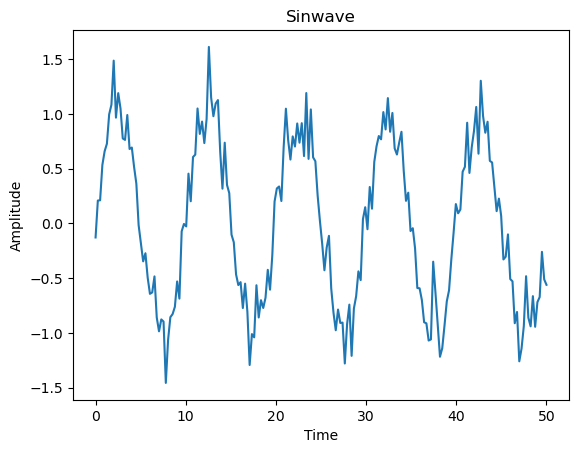

In [1]:
from statsmodels.tsa.arima.model import ARIMA 
import numpy as np 
import matplotlib.pyplot as plt

f = 0.1 
A = 1 
duration = 50 
fs = 200

rng = np.random.default_rng()

noise = rng.normal( loc = 0, scale = 0.2, size = 200)

t = np.linspace(0,duration, fs)

y_noisy = A*np.sin(2*np.pi*f*t) + noise

plt.plot(t,y_noisy)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Sinwave")
plt.show()

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(2, 0, 0)   Log Likelihood                 -21.641
Date:                Tue, 12 May 2026   AIC                             51.282
Time:                        03:18:16   BIC                             64.475
Sample:                             0   HQIC                            56.621
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0436      0.317     -0.138      0.891      -0.665       0.578
ar.L1          0.7353      0.074      9.913      0.000       0.590       0.881
ar.L2          0.2036      0.074      2.757      0.0

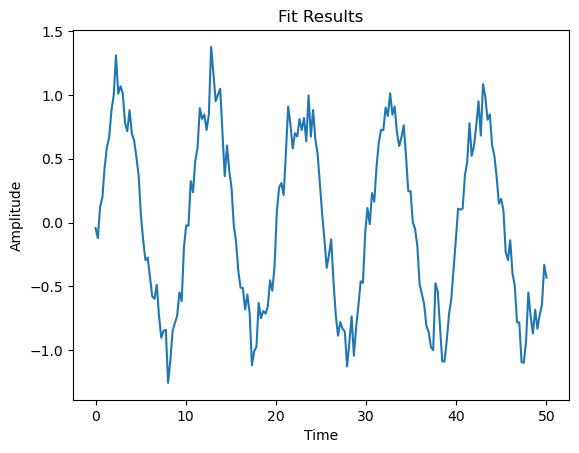

In [2]:
model = ARIMA(y_noisy, order = (2,0,0))

fit = model.fit()


fitted_values = fit.predict()

plt.figure()
plt.plot(t,fitted_values)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Fit Results")

print(fit.summary())


In [3]:
residuals = fit.resid

In [4]:
print(residuals)
print(len(residuals))

[-0.08546953  0.33065823  0.08628793  0.33859059  0.22619229  0.13672971
  0.32966495  0.20569454  0.48904108 -0.34521177  0.17931096 -0.01824213
 -0.23618508 -0.01906989  0.27372003 -0.20091396 -0.00594469 -0.12966361
 -0.15539015 -0.3839837  -0.23845201 -0.20932421  0.02168259 -0.22220669
 -0.22059108 -0.05380952  0.11324898 -0.37232175 -0.25265897  0.02565425
 -0.0481978  -0.61640018  0.19215917  0.22504332  0.02114264  0.02407922
  0.20116508 -0.13920171  0.54332275  0.19043147 -0.00659002  0.47821727
 -0.12351913  0.36732383  0.14371992  0.46676853 -0.07970614  0.11767264
 -0.11383685  0.22702981  0.76384155 -0.22727042 -0.191729    0.14304382
  0.12498071 -0.39296546 -0.39127467  0.37285568 -0.25206652 -0.12970668
 -0.37504586 -0.15020388 -0.31486554 -0.18317705 -0.02494842 -0.26113041
  0.12993116 -0.24332125 -0.58418271  0.10723039 -0.03140645  0.40868295
 -0.22937466  0.04837981 -0.07923023  0.03446441  0.23493119 -0.15243244
  0.24435389  0.53867088  0.23352104  0.06427505 -0

In [5]:
from sampling_methods import sample_gaussian, sample_empirical, sample_kde, sample_block

kde_results = sample_kde(residuals, 1000)

In [6]:
from diagnostics import diagnostic_plot

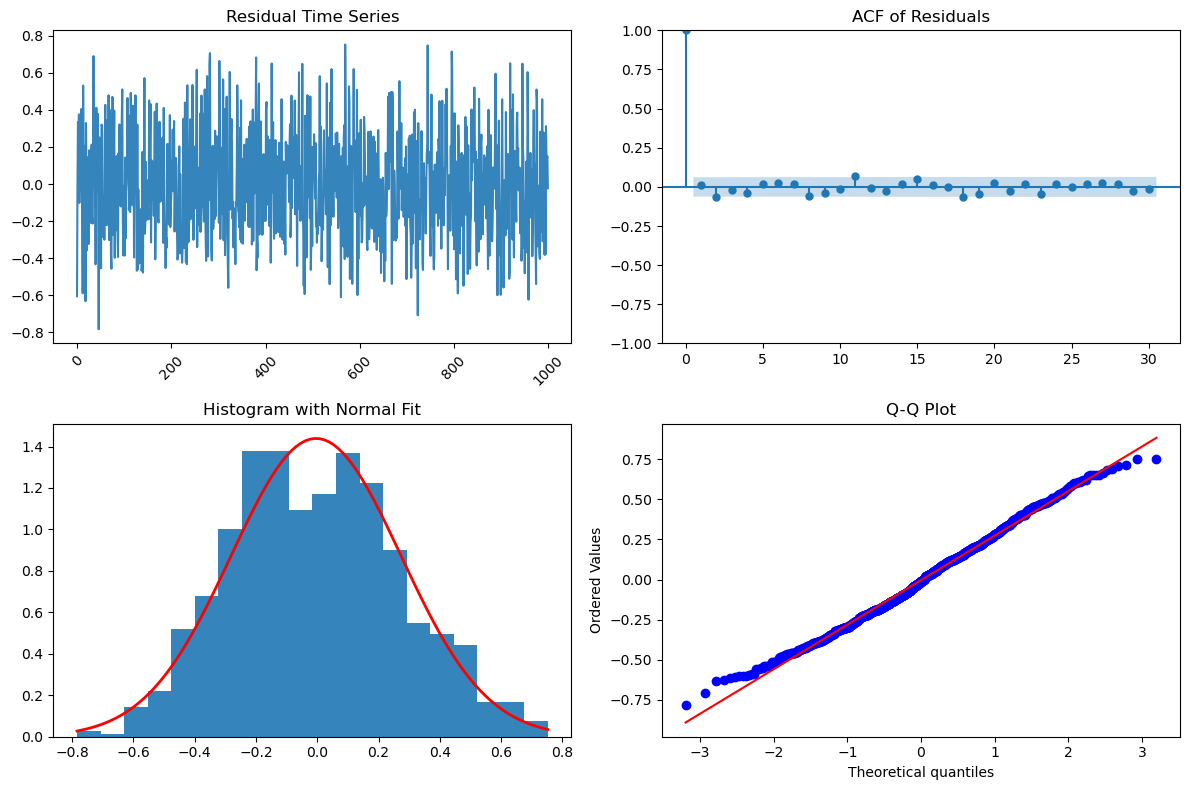

In [7]:
diagnostic_plot(kde_results)

In [8]:
gaussian_results = sample_gaussian(residuals, 1000)

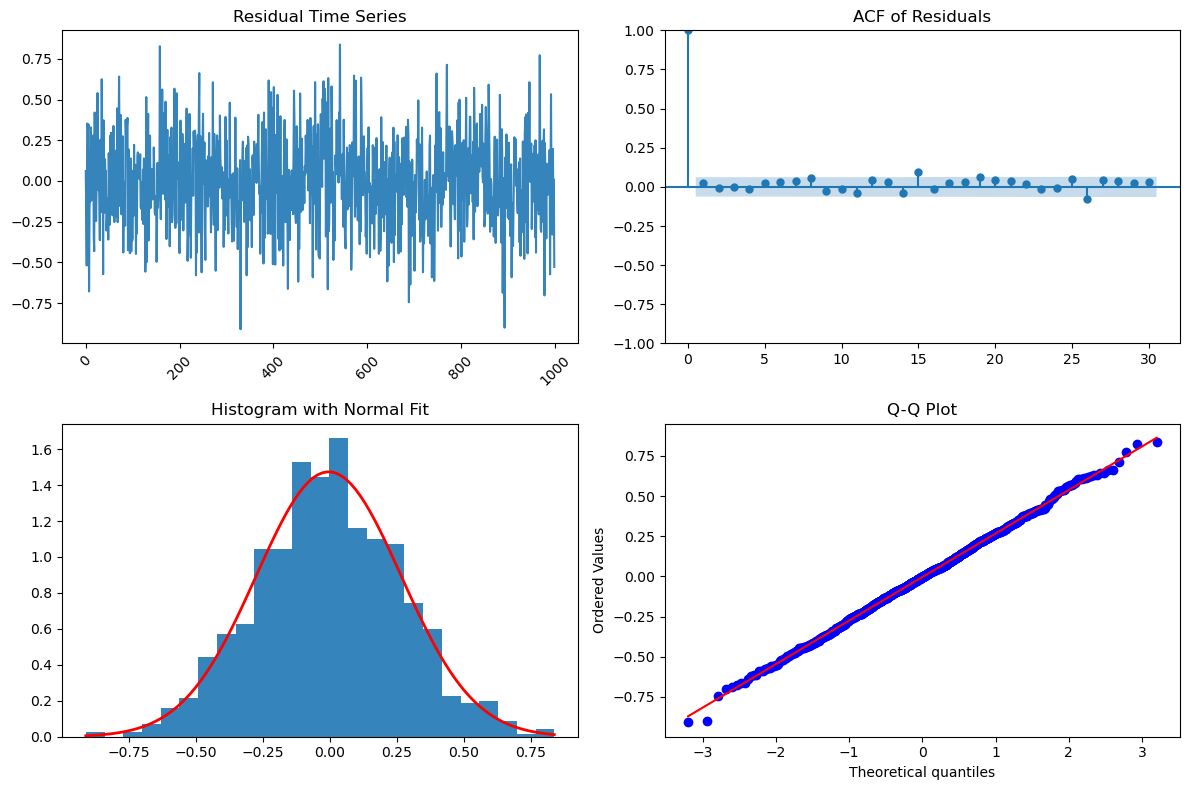

In [9]:
diagnostic_plot(gaussian_results)

In [10]:
empirical_results = sample_empirical(residuals, 1000)

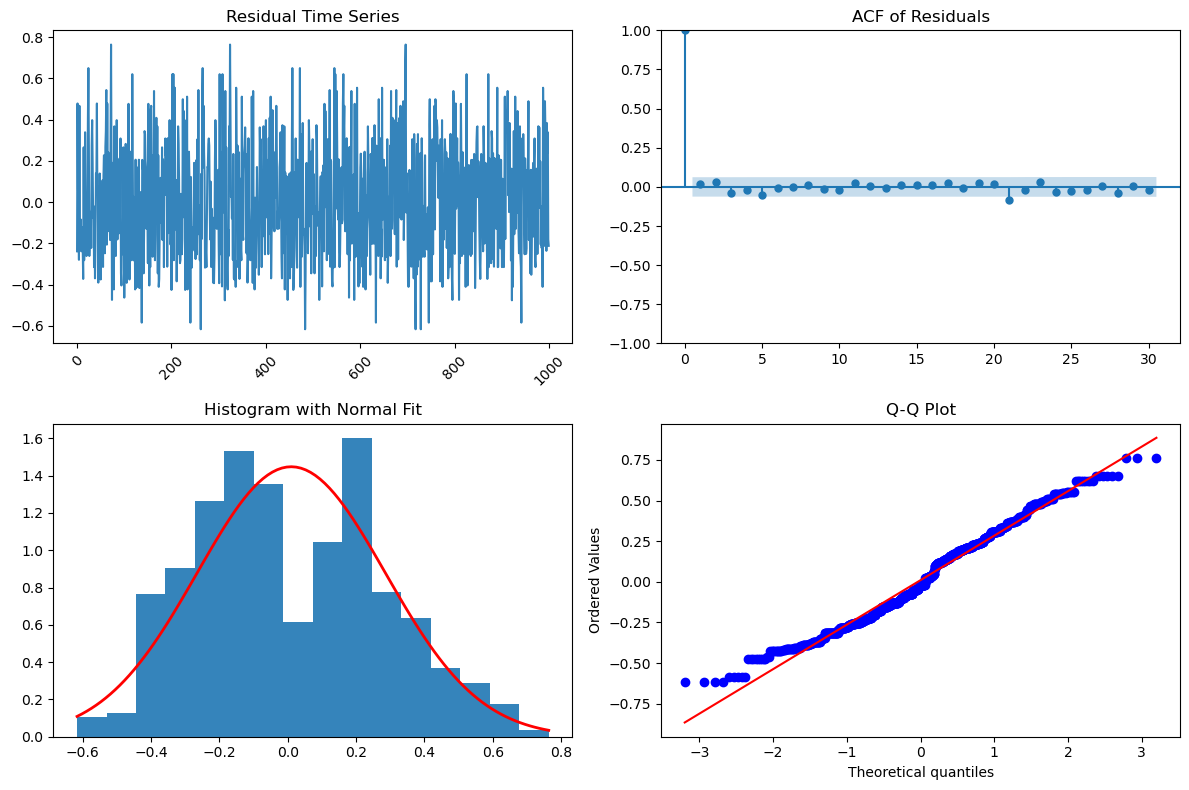

In [11]:
diagnostic_plot(empirical_results)

In [12]:
from arch.bootstrap import optimal_block_length

opt = optimal_block_length(residuals)

print(opt)
print(opt.columns)

   stationary   circular
0   11.586051  13.262717
Index(['stationary', 'circular'], dtype='str')


In [ ]:
block_results = sample_block(residuals, 1000)



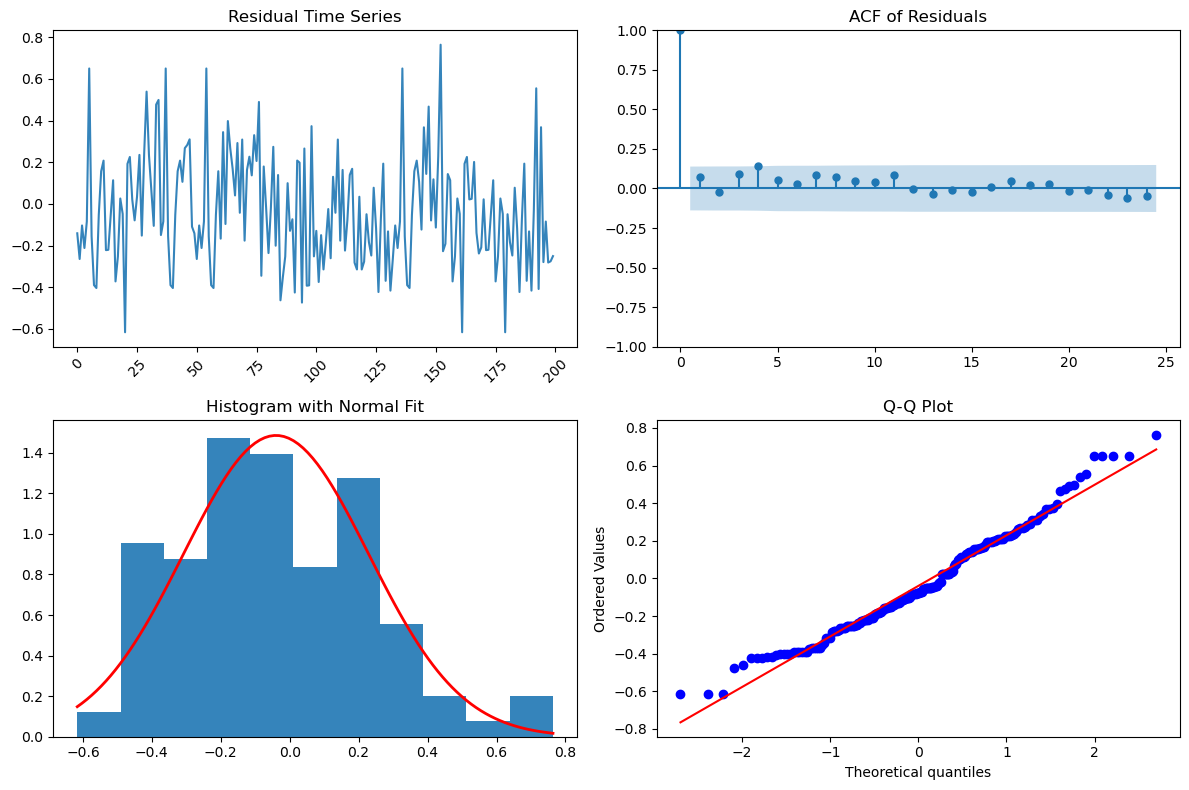

In [22]:
diagnostic_plot(block_results)

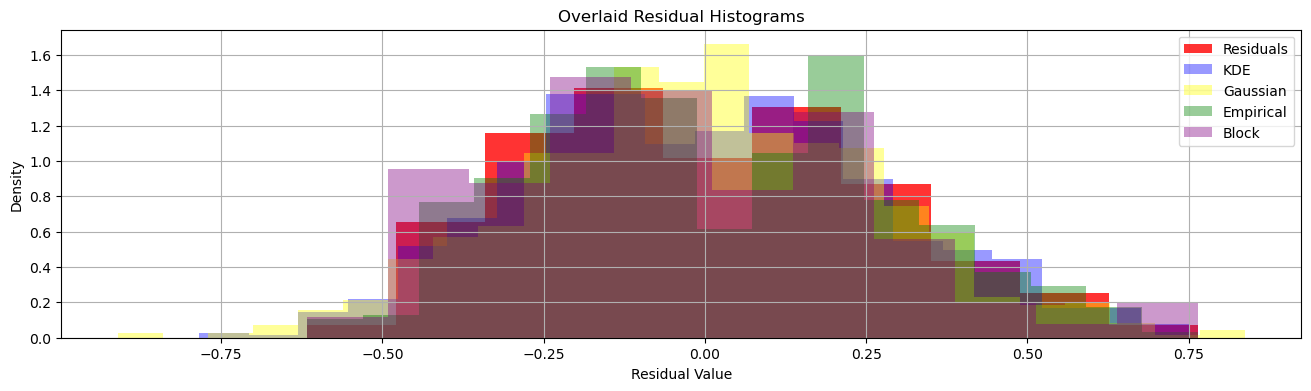

In [23]:
plt.figure(figsize = (16,4))

plt.hist(residuals, bins = 'auto', density = True, alpha = 0.8, color= 'red', label = 'Residuals')
plt.hist(kde_results, bins = 'auto', density = True, alpha = 0.4, color='blue' , label = 'KDE')
plt.hist(gaussian_results, bins = 'auto', density = True, alpha = 0.4, color = 'yellow' , label = 'Gaussian')
plt.hist(empirical_results, bins = 'auto', density = True, alpha = 0.4, color = 'green' , label = 'Empirical')
plt.hist(block_results, bins = 'auto', density = True, alpha = 0.4, color = 'purple' , label = 'Block')

plt.xlabel("Residual Value")
plt.ylabel("Density")
plt.title("Overlaid Residual Histograms")
plt.legend()
plt.grid(True)

plt.show()

In [24]:
from scipy.stats import ks_2samp

gaussian_ks_stat, gaussian_p_value = ks_2samp(residuals, gaussian_results)
empirical_ks_stat, empirical_p_value = ks_2samp(residuals, empirical_results)
kde_ks_stat, kde_p_value = ks_2samp(residuals, kde_results)
block_ks_stat, block_p_value = ks_2samp(residuals, block_results)


print("Block KS Statistic:", block_ks_stat)
print("Block P-value:", block_p_value)

print("KDE KS Statistic:", kde_ks_stat)
print("KDE P-value:", kde_p_value)

print("Empirical KS Statistic:", empirical_ks_stat)
print("Empirical P-value:", empirical_p_value)

print("Gaussian KS Statistic:", gaussian_ks_stat)
print("Gaussian P-value:", gaussian_p_value)

Block KS Statistic: 0.09
Block P-value: 0.39352743357720954
KDE KS Statistic: 0.036
KDE P-value: 0.9788237598011202
Empirical KS Statistic: 0.034
Empirical P-value: 0.9883981468955733
Gaussian KS Statistic: 0.055
Gaussian P-value: 0.6807925967145928


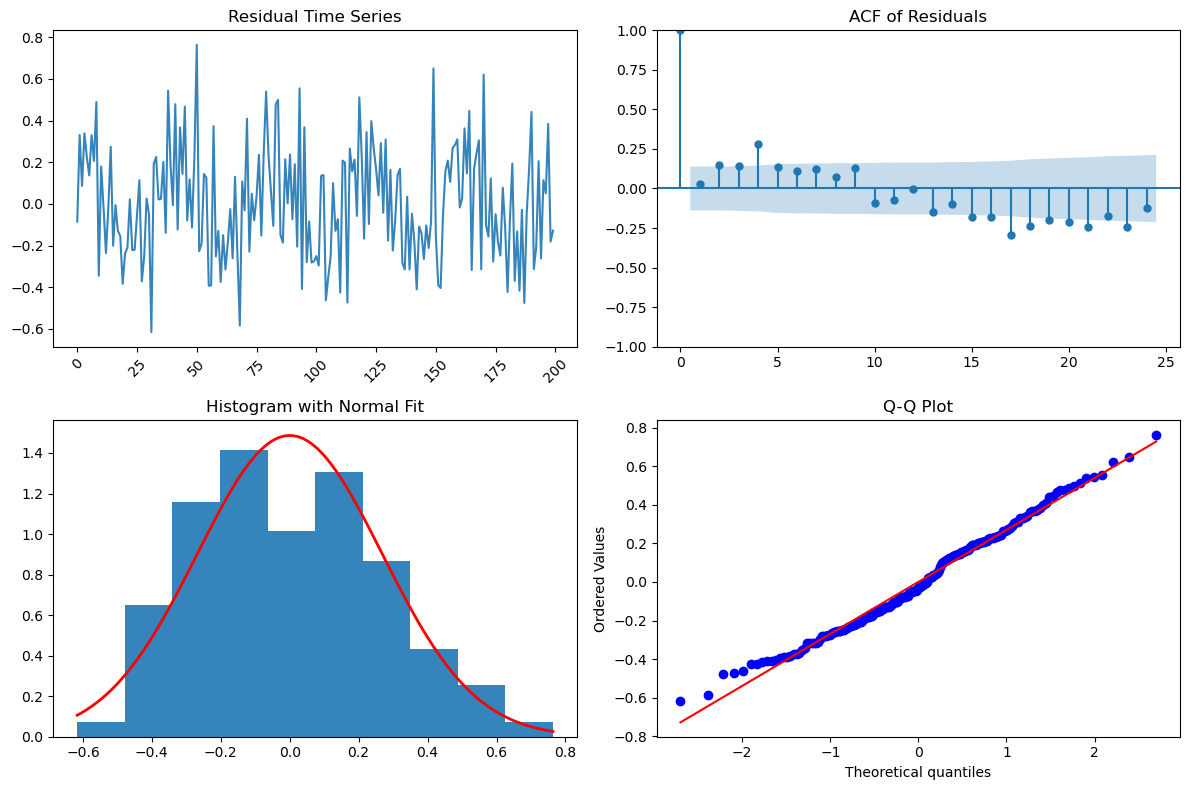

In [25]:
diagnostic_plot(residuals)

Looks like the block resampling gave us the highest p value with the lowest ks statistic, which means it keeps the original structure the best. It's also visually keeping the structure most similar to the residuals. 

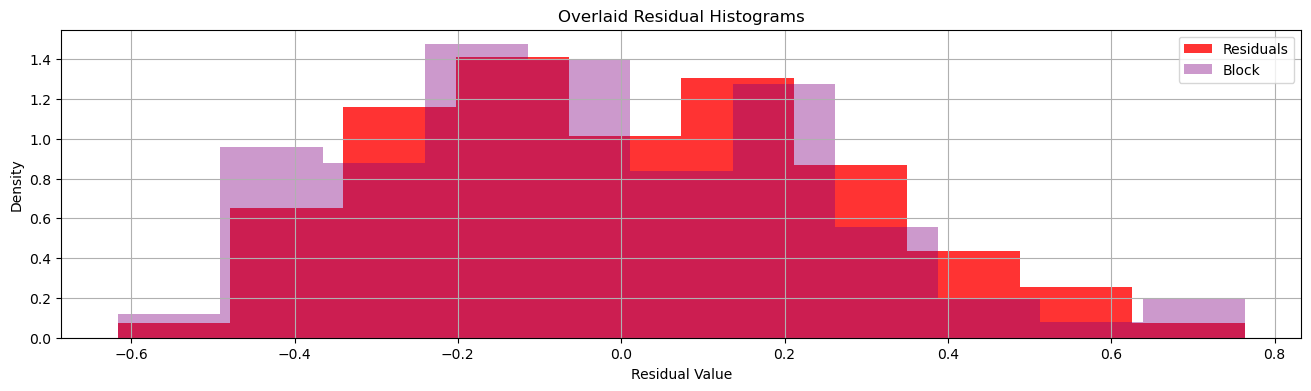

In [26]:
plt.figure(figsize = (16,4))

plt.hist(residuals, bins = 'auto', density = True, alpha = 0.8, color= 'red', label = 'Residuals')
plt.hist(block_results, bins = 'auto', density = True, alpha = 0.4, color = 'purple' , label = 'Block')

plt.xlabel("Residual Value")
plt.ylabel("Density")
plt.title("Overlaid Residual Histograms")
plt.legend()
plt.grid(True)

plt.show()

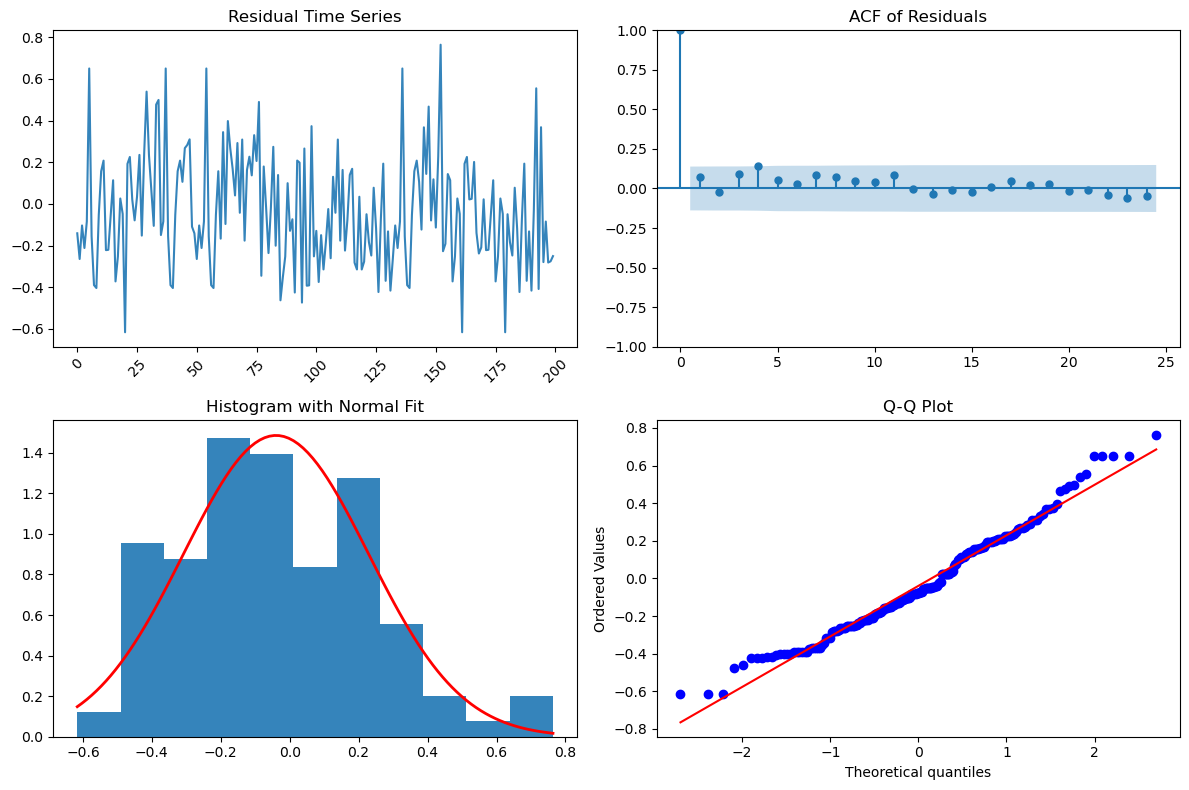

In [27]:
diagnostic_plot(block_results)

Now, let's use these functions to get some error samples and add them to the sin wave. We will compare the noisy signal sin wave after. 

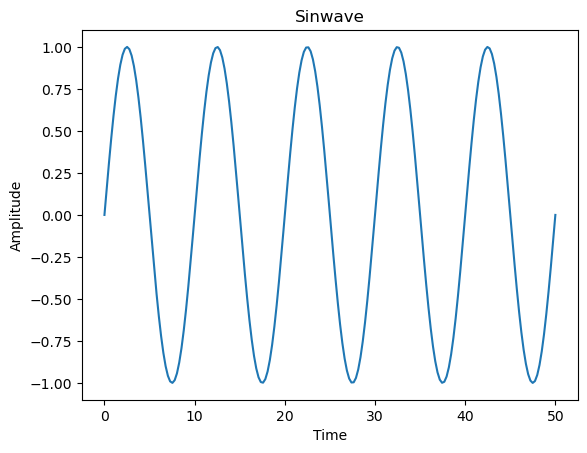

In [28]:
from statsmodels.tsa.arima.model import ARIMA 
import numpy as np 
import matplotlib.pyplot as plt

f = 0.1 
A = 1 
duration = 50 
fs = 200

t = np.linspace(0,duration, fs)

y = A*np.sin(2*np.pi*f*t) 

plt.plot(t,y)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Sinwave")
plt.show()

In [29]:
y_perturbed = y + block_results

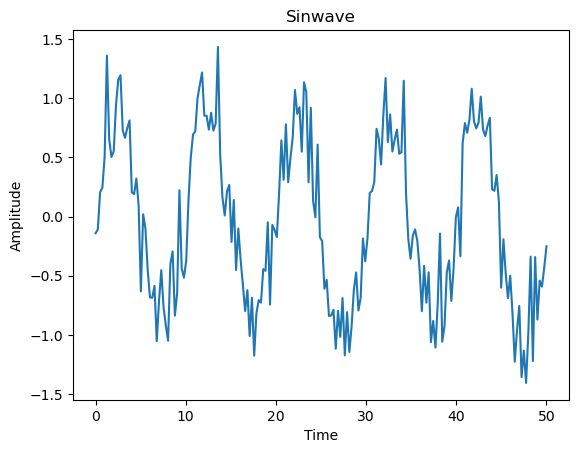

In [30]:
plt.plot(t,y_perturbed)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Sinwave")
plt.show()

In [31]:
ensemble = []

for i in range(20):

    block_results = sample_block(residuals, len(y))

    y_perturbed = y + block_results

    ensemble.append(y_perturbed)

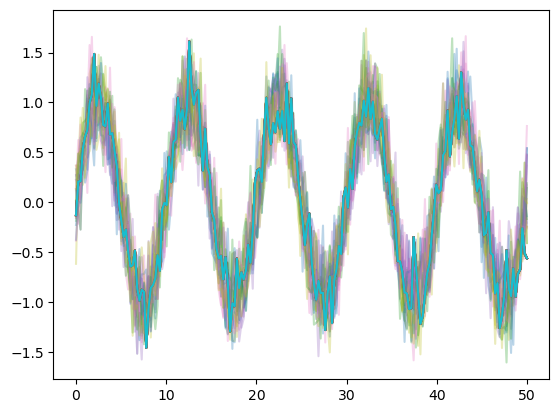

In [33]:
plt.figure()

for i in range(20):
    plt.plot(t, ensemble[i], alpha = 0.3)
    plt.plot(t, y_noisy)

In [34]:
ensemble_block = []

for i in range(20):

    block_results = sample_block(residuals, 200)

    y_perturbed_block = y + block_results

    ensemble_block.append(y_perturbed_block)



ensemble_gaussian = []

for i in range(20):

    gaussian_results = sample_gaussian(residuals, 200)

    y_perturbed_gaussian = y + gaussian_results

    ensemble_gaussian.append(y_perturbed_gaussian)



ensemble_empirical = []

for i in range(20):

    empirical_results = sample_empirical(residuals, 200)

    y_perturbed_empirical = y + empirical_results

    ensemble_empirical.append(y_perturbed_empirical)



ensemble_kde = []

for i in range(20):

    kde_results = sample_kde(residuals, 200)

    y_perturbed_kde = y + kde_results

    ensemble_kde.append(y_perturbed_kde)

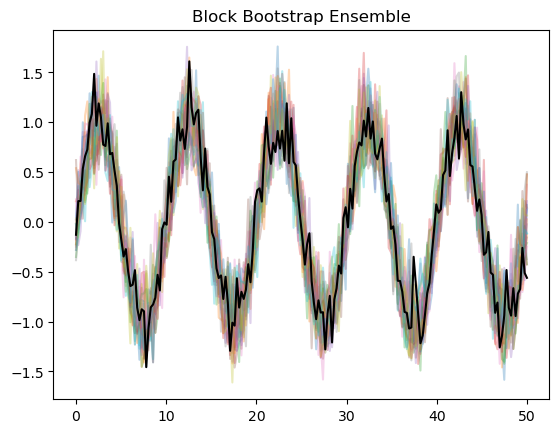

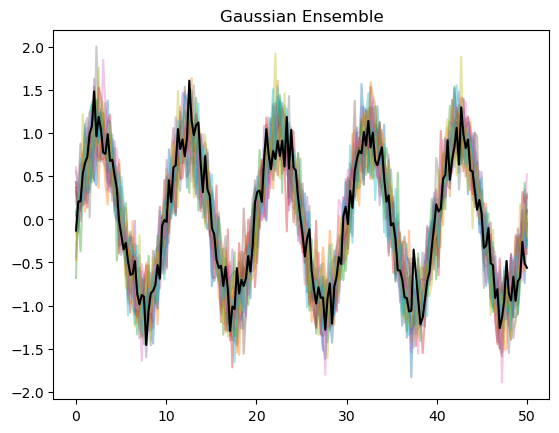

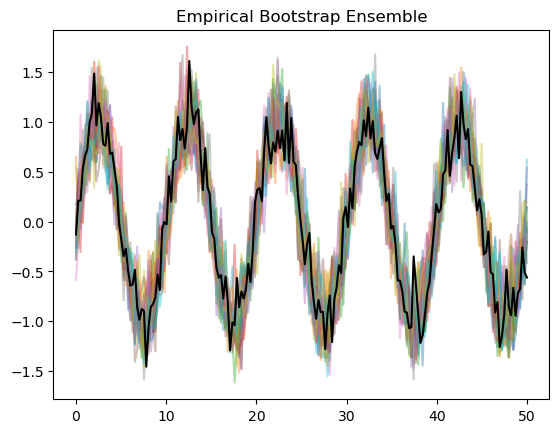

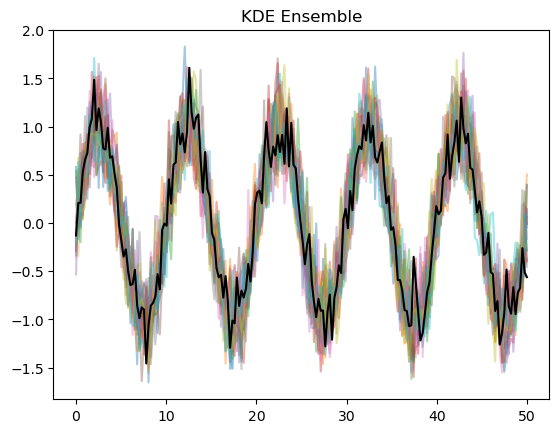

In [36]:
plt.figure()

for i in range(20):
    plt.plot(t, ensemble_block[i], alpha=0.3)

plt.plot(t, y_noisy, color='black')

plt.title("Block Bootstrap Ensemble")
plt.show()


plt.figure()

for i in range(20):
    plt.plot(t, ensemble_gaussian[i], alpha=0.4)

plt.plot(t, y_noisy, color='black')

plt.title("Gaussian Ensemble")
plt.show()


plt.figure()

for i in range(20):
    plt.plot(t, ensemble_empirical[i], alpha=0.4)

plt.plot(t, y_noisy, color='black')

plt.title("Empirical Bootstrap Ensemble")
plt.show()


plt.figure()

for i in range(20):
    plt.plot(t, ensemble_kde[i], alpha=0.4)

plt.plot(t, y_noisy, color='black')

plt.title("KDE Ensemble")
plt.show()